# 04 -- ArcFace v5: ResNet34 + SubCenterArcFace + Phase 3 Contrastive

**v5 improvements over v4:**
- Backbone: ResNet18 -> ResNet34 (21.3M params, deeper feature hierarchy)
- Pooling: GAP -> GeM pooling (learnable p, suppresses white-background noise)
- Embedding head: FC -> BN-Dropout-FC-BN (InsightFace standard)
- Loss: ArcFace -> SubCenterArcFace K=3 (3 prototypes per writer)
- Margin curriculum: 0.1->0.5 over first 15 epochs (prevents early collapse)
- Augmentation: + ElasticTransform + RandomPerspective
- Mining: per-class EMA -> per-sample EMA (finer-grained difficulty)
- Phase 3: contrastive fine-tuning on genuine-forgery pairs (10 epochs)
- TTA: N=8 augmented views averaged at inference

**Training corpus**: 251 writers, 6884 genuine images
**Target**: EER <= 5.0% (from 7.91% in v4)

---
## Section 0 -- Setup

In [1]:
import sys, re, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as models

from sklearn import metrics as sk_metrics
from sklearn.decomposition import PCA

def _find_project_root(start):
    for p in [start] + list(start.parents):
        if (p / '.git').exists() or (p / 'requirements.txt').exists():
            return p
    raise RuntimeError(f'Cannot find project root from {start}')

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.seed import set_seed
from src.metrics.verification import compute_metrics

SEED    = 42
set_seed(SEED)
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DS_ROOT = PROJECT_ROOT / 'datasets'
print('Device      :', DEVICE)
print('Dataset root:', DS_ROOT)

Device      : cuda
Dataset root: /home/jovyan/vault/datasets


---
## Section 1 -- Multi-Dataset Scanners

In [2]:
def scan_cedar(root):
    root = Path(root)
    pat_o = re.compile(r'^original_(\d+)_(\d+)\.png$',  re.I)
    pat_f = re.compile(r'^forgeries_(\d+)_(\d+)\.png$', re.I)
    rows  = []
    for fp in (root/'full_org').iterdir():
        m = pat_o.match(fp.name)
        if m: rows.append({'path':str(fp),'writer_uid':f'cedar_{int(m.group(1)):03d}','label':'genuine','dataset':'cedar'})
    for fp in (root/'full_forg').iterdir():
        m = pat_f.match(fp.name)
        if m: rows.append({'path':str(fp),'writer_uid':f'cedar_{int(m.group(1)):03d}','label':'forgery','dataset':'cedar'})
    return pd.DataFrame(rows)

def scan_gpds150(root):
    root  = Path(root)
    pat_g = re.compile(r'^c-(\d+)-(\d+)',  re.I)
    pat_f = re.compile(r'^cf-(\d+)-(\d+)', re.I)
    rows  = []
    for fp in (root/'train'/'genuine').iterdir():
        m = pat_g.match(fp.name)
        if m: rows.append({'path':str(fp),'writer_uid':f'gpds_{int(m.group(1)):03d}','label':'genuine','dataset':'gpds150'})
    for fp in (root/'train'/'forge').iterdir():
        m = pat_f.match(fp.name)
        if m: rows.append({'path':str(fp),'writer_uid':f'gpds_{int(m.group(1)):03d}','label':'forgery','dataset':'gpds150'})
    for wd in (root/'test').iterdir():
        if not wd.is_dir(): continue
        for fp in (wd/'genuine').iterdir():
            m = pat_g.match(fp.name)
            if m: rows.append({'path':str(fp),'writer_uid':f'gpds_{int(m.group(1)):03d}','label':'genuine','dataset':'gpds150'})
        for fp in (wd/'forge').iterdir():
            m = pat_f.match(fp.name)
            if m: rows.append({'path':str(fp),'writer_uid':f'gpds_{int(m.group(1)):03d}','label':'forgery','dataset':'gpds150'})
    return pd.DataFrame(rows)

def scan_sigcomp2011(root):
    base = Path(root)/'trainingSet'/'OfflineSignatures'
    rows = []
    for lang, prefix in [('Dutch','sc11d'),('Chinese','sc11c')]:
        gen = base/lang/'TrainingSet'/'Offline Genuine'
        pat = re.compile(r'^(\d+)_', re.I)
        for fp in gen.iterdir():
            m = pat.match(fp.name)
            if m and fp.is_file():
                rows.append({'path':str(fp),'writer_uid':f'{prefix}_{int(m.group(1)):03d}','label':'genuine','dataset':f'sc2011_{lang.lower()}'})
    return pd.DataFrame(rows)

def scan_sigcomp2009(root):
    data = Path(root)/'NISDCC-offline-all-001-051-6g'/'NISDCC-offline-all-001-051-6g'
    pat  = re.compile(r'^NISDCC-(\d+)_', re.I)
    rows = []
    for fp in data.iterdir():
        m = pat.match(fp.name)
        if m and fp.is_file():
            rows.append({'path':str(fp),'writer_uid':f'sc09_{int(m.group(1)):03d}','label':'genuine','dataset':'sc2009'})
    return pd.DataFrame(rows)

print('Scanning...')
df_cedar = scan_cedar(DS_ROOT/'CEDAR')
df_gpds  = scan_gpds150(DS_ROOT/'GPDS150')
df_sc11  = scan_sigcomp2011(DS_ROOT/'sigComp2011-trainingSet')
df_sc09  = scan_sigcomp2009(DS_ROOT/'SigComp2009-training')
df_all   = pd.concat([df_cedar,df_gpds,df_sc11,df_sc09], ignore_index=True)
print(df_all.groupby(['dataset','label'])['writer_uid'].agg(writers='nunique',images='count').to_string())
print(f'\nTotal unique writers: {df_all["writer_uid"].nunique()}  |  Total images: {len(df_all)}')


Scanning...
                        writers  images
dataset        label                   
cedar          forgery       55    1320
               genuine       55    1320
gpds150        forgery      150    4500
               genuine      150    3600
sc2009         genuine       43    1898
sc2011_chinese genuine       10     235
sc2011_dutch   genuine       10     239

Total unique writers: 268  |  Total images: 13112


---
## Section 2 -- Training / Evaluation Split

In [3]:
cedar_writers = np.array(sorted(df_cedar['writer_uid'].unique()))
rng = np.random.default_rng(SEED)
rng.shuffle(cedar_writers)
n = len(cedar_writers); n_tr = int(round(n*0.70)); n_v = int(round(n*0.15))
cedar_train_wids = set(cedar_writers[:n_tr])
cedar_val_wids   = set(cedar_writers[n_tr:n_tr+n_v])
cedar_test_wids  = set(cedar_writers[n_tr+n_v:])

other_train_wids = (set(df_gpds['writer_uid'].unique()) |
                    set(df_sc11['writer_uid'].unique()) |
                    set(df_sc09['writer_uid'].unique()))
all_train_wids  = cedar_train_wids | other_train_wids
sorted_train    = sorted(all_train_wids)
writer_to_class = {wid: i for i, wid in enumerate(sorted_train)}
NUM_CLASSES     = len(sorted_train)

print(f'CEDAR split -- train:{len(cedar_train_wids)}  val:{len(cedar_val_wids)}  test:{len(cedar_test_wids)}')
print(f'Total training classes: {NUM_CLASSES}')

CEDAR split -- train:38  val:8  test:9
Total training classes: 251


---
## Section 3 -- Transforms and Datasets

**New in v5:**
- ElasticTransform (torchvision>=0.14): deforms individual ink strokes
- RandomPerspective: simulates non-flat document scanning
- `tta_tfm`: stochastic transform for test-time augmentation
- `SignatureClassDataset` now returns `(img, label, idx)` for per-sample mining
- `ForgeryPairDataset`: genuine-genuine and genuine-forgery pairs for Phase 3

In [4]:
import torchvision
_tv = tuple(int(x) for x in torchvision.__version__.split('.')[:2])
HAS_ELASTIC = _tv >= (0, 14)
print(f'torchvision {torchvision.__version__}  |  ElasticTransform available: {HAS_ELASTIC}')

IMG_SIZE = 224
BATCH    = 64

_base_aug = [
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomAffine(degrees=8, translate=(0.05,0.05), scale=(0.93,1.07), fill=255),
]
if HAS_ELASTIC:
    _base_aug += [
        T.ElasticTransform(alpha=50.0, sigma=5.0, fill=255),
        T.RandomPerspective(distortion_scale=0.15, p=0.4, fill=255),
    ]
else:
    _base_aug += [T.RandomPerspective(distortion_scale=0.15, p=0.4, fill=255)]

train_tfm = T.Compose(_base_aug + [
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
    T.Lambda(lambda x: x + 0.015*torch.randn_like(x)),
])
eval_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])
tta_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomAffine(degrees=5, translate=(0.03,0.03), scale=(0.96,1.04), fill=255),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])

class SignatureClassDataset(Dataset):
    """Returns (img, class_label, dataset_idx) -- idx enables per-sample mining."""
    def __init__(self, df, writer_to_class, writer_uid_set, transform=None):
        sub = df[(df['writer_uid'].isin(writer_uid_set)) & (df['label']=='genuine')]
        self.records   = sub[['path','writer_uid']].reset_index(drop=True)
        self.w2c       = writer_to_class
        self.transform = transform
    def __len__(self): return len(self.records)
    def get_class_indices(self):
        return torch.tensor([self.w2c[uid] for uid in self.records['writer_uid']])
    def __getitem__(self, idx):
        row = self.records.iloc[idx]
        img = Image.open(row['path']).convert('L')
        if self.transform: img = self.transform(img)
        return img, self.w2c[row['writer_uid']], idx

class SiamesePairDataset(Dataset):
    def __init__(self, pairs_df, transform=None):
        self.pairs = pairs_df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        row = self.pairs.iloc[idx]
        a = Image.open(row['path_a']).convert('L')
        b = Image.open(row['path_b']).convert('L')
        if self.transform: a = self.transform(a); b = self.transform(b)
        return a, b, torch.tensor(row['label'], dtype=torch.float32)

class ForgeryPairDataset(Dataset):
    """Genuine-genuine (label=1) and genuine-forgery (label=0) pairs for Phase 3."""
    def __init__(self, df, wid_set, n_pairs=20000, seed=7, neg_ratio=0.5, transform=None):
        rng = np.random.default_rng(seed)
        gen, forg = {}, {}
        for wid, grp in df[df['writer_uid'].isin(wid_set)].groupby('writer_uid'):
            g = grp[grp['label']=='genuine']['path'].tolist()
            f = grp[grp['label']=='forgery']['path'].tolist()
            if g: gen[wid] = g
            if f and g: forg[wid] = f
        writers_f = sorted(set(gen) & set(forg))
        n_neg = int(round(n_pairs * neg_ratio)); n_pos = n_pairs - n_neg
        rows = []
        for _ in range(n_pos):
            w = writers_f[rng.integers(len(writers_f))]
            g = gen[w]
            if len(g) < 2: continue
            i, j = rng.choice(len(g), 2, replace=False)
            rows.append({'path_a': g[int(i)], 'path_b': g[int(j)], 'label': 1})
        for _ in range(n_neg):
            w = writers_f[rng.integers(len(writers_f))]
            rows.append({'path_a': gen[w][rng.integers(len(gen[w]))],
                         'path_b': forg[w][rng.integers(len(forg[w]))], 'label': 0})
        self.pairs = pd.DataFrame(rows).sample(frac=1, random_state=seed).reset_index(drop=True)
        self.transform = transform
        print(f'ForgeryPairDataset: {len(self.pairs):,} pairs from {len(writers_f)} writers '
              f'({int(self.pairs["label"].sum())} pos / {int((1-self.pairs["label"]).sum())} neg)')
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        row = self.pairs.iloc[idx]
        a = Image.open(row['path_a']).convert('L')
        b = Image.open(row['path_b']).convert('L')
        if self.transform: a = self.transform(a); b = self.transform(b)
        return a, b, torch.tensor(row['label'], dtype=torch.float32)

train_cls_ds    = SignatureClassDataset(df_all, writer_to_class, all_train_wids, transform=train_tfm)
N_TRAIN         = len(train_cls_ds)
sample_loss_ema = torch.ones(N_TRAIN, dtype=torch.float32)

def make_mining_loader(sample_weights):
    sampler = WeightedRandomSampler(sample_weights.clamp(min=1e-6).tolist(), N_TRAIN, replacement=True)
    return DataLoader(train_cls_ds, batch_size=BATCH, sampler=sampler,
                      num_workers=0, pin_memory=DEVICE.type=='cuda')

x_sample, y_sample, _ = next(iter(make_mining_loader(sample_loss_ema)))
print(f'Train images  : {N_TRAIN:,}  across {NUM_CLASSES} classes')
print(f'Batch shape   : {x_sample.shape}')

torchvision 0.24.1+cu128  |  ElasticTransform available: True
Train images  : 6,884  across 251 classes
Batch shape   : torch.Size([64, 1, 224, 224])


---
## Section 4 -- SubCenterArcFace Loss (K=3 sub-centers per class)

Each writer gets K=3 prototype vectors instead of 1.
The closest sub-center is selected per sample: `cos_t = max_k cos(theta_{i,k})`.
This handles intra-class variation (relaxed vs formal vs tired signing style).
Weight shape: (251 x 3, 256) = (753, 256).

In [5]:
class SubCenterArcFace(nn.Module):
    """ArcFace with K sub-centers per class."""
    def __init__(self, emb_dim, num_classes, K=3, scale=64.0, margin=0.5):
        super().__init__()
        self.K           = K
        self.num_classes = num_classes
        self.scale       = scale
        self.weight = nn.Parameter(torch.empty(num_classes * K, emb_dim))
        nn.init.xavier_uniform_(self.weight)
        self._update_margin(margin)

    def _update_margin(self, m):
        self.margin = m
        self.cos_m  = math.cos(m)
        self.sin_m  = math.sin(m)
        self.th     = math.cos(math.pi - m)
        self.mm     = math.sin(math.pi - m) * m

    def forward(self, embeddings, labels, reduction='mean'):
        B       = embeddings.size(0)
        emb_n   = F.normalize(embeddings, dim=1)
        w_n     = F.normalize(self.weight, dim=1)
        cos_all = F.linear(emb_n, w_n).clamp(-1+1e-7, 1-1e-7)         # (B, C*K)
        cos_t   = cos_all.view(B, self.num_classes, self.K).max(dim=2).values  # (B, C)
        sin_t   = torch.sqrt(1.0 - cos_t**2)
        cos_tm  = cos_t * self.cos_m - sin_t * self.sin_m
        cos_tm  = torch.where(cos_t > self.th, cos_tm, cos_t - self.mm)
        one_hot = torch.zeros_like(cos_t).scatter_(1, labels.view(-1,1).long(), 1.0)
        output  = ((one_hot * cos_tm) + ((1-one_hot) * cos_t)) * self.scale
        return F.cross_entropy(output, labels.long(), reduction=reduction)

K_SUB   = 3
EMB_DIM = 256

_arc = SubCenterArcFace(EMB_DIM, NUM_CLASSES, K=K_SUB).to(DEVICE)
_e   = torch.randn(4, EMB_DIM).to(DEVICE)
_l   = torch.randint(0, NUM_CLASSES, (4,)).to(DEVICE)
print(f'Weight shape : {_arc.weight.shape}  -- ({NUM_CLASSES} classes x {K_SUB} sub-centers x {EMB_DIM} dim)')
print(f'Loss (mean)  : {_arc(_e, _l, "mean").item():.4f}')
del _arc, _e, _l

Weight shape : torch.Size([753, 256])  -- (251 classes x 3 sub-centers x 256 dim)
Loss (mean)  : 40.2131


---
## Section 5 -- ResNet34 + GeM + InsightFace Head

**GeMPool**: replaces GAP. Learnable p initialised to 3 (between avg and max pooling).
Suppresses white-background feature activations and focuses on ink-stroke regions.

**InsightFace head**: BN -> Dropout(0.4) -> Linear(512->256) -> BN(affine=False).
Standard setup from face recognition; stabilises embedding scale before L2 norm.

In [6]:
class GeMPool(nn.Module):
    """Generalized Mean Pooling. p=1 -> avg, p->inf -> max."""
    def __init__(self, p=3, eps=1e-6):
        super().__init__()
        self.p   = nn.Parameter(torch.ones(1) * p)
        self.eps = eps
    def forward(self, x):
        return F.adaptive_avg_pool2d(x.clamp(min=self.eps).pow(self.p), 1).pow(1./self.p)

def build_resnet34_grayscale(emb_dim=256):
    try:
        from torchvision.models import ResNet34_Weights
        net = models.resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)
    except (ImportError, AttributeError):
        net = models.resnet34(pretrained=True)
    # Grayscale adaptation: average RGB conv1 weights [64,3,7,7] -> [64,1,7,7]
    w = net.conv1.weight.data
    gray_conv = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    gray_conv.weight.data = w.mean(dim=1, keepdim=True)
    net.conv1 = gray_conv
    # GeM pooling replaces adaptive average pool
    net.avgpool = GeMPool(p=3)
    # InsightFace embedding head: BN -> Dropout -> Linear -> BN(no affine)
    in_f = net.fc.in_features  # 512 for ResNet34
    net.fc = nn.Sequential(
        nn.BatchNorm1d(in_f),
        nn.Dropout(0.4),
        nn.Linear(in_f, emb_dim),
        nn.BatchNorm1d(emb_dim, affine=False),
    )
    return net

backbone = build_resnet34_grayscale(EMB_DIM).to(DEVICE)
arc_head = SubCenterArcFace(EMB_DIM, NUM_CLASSES, K=K_SUB, scale=64.0, margin=0.1).to(DEVICE)

n_bb = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
n_hd = sum(p.numel() for p in arc_head.parameters()  if p.requires_grad)
print(f'Backbone params  : {n_bb:,}')
print(f'ArcFace params   : {n_hd:,}')
with torch.no_grad():
    emb  = backbone(x_sample.to(DEVICE))
    loss = arc_head(emb, y_sample.to(DEVICE))
print(f'Embedding shape  : {emb.shape}')
print(f'Initial loss     : {loss.item():.4f}')
print(f'GeM p (initial)  : {backbone.avgpool.p.item():.3f}')

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 115MB/s]


Backbone params  : 21,410,753
ArcFace params   : 192,768
Embedding shape  : torch.Size([64, 256])
Initial loss     : 17.1229
GeM p (initial)  : 3.000


---
## Section 6 -- Phase 1: Full Network Training (30 epochs)

**Margin curriculum**: margin ramps from 0.1 to 0.5 over the first 15 epochs.
Small margin early lets embeddings organise before angular boundaries tighten.

**Per-sample mining**: each training image maintains its own EMA loss score.
Only the hard individual images are oversampled -- not the entire class.

**LR**: 3-epoch linear warmup (0.1x -> 1x) then cosine decay to 1e-5.
**Gradient clipping**: max_norm=1.0.

In [7]:
set_seed(SEED)

backbone = build_resnet34_grayscale(EMB_DIM).to(DEVICE)
arc_head = SubCenterArcFace(EMB_DIM, NUM_CLASSES, K=K_SUB, scale=64.0, margin=0.1).to(DEVICE)

params_p1    = list(backbone.parameters()) + list(arc_head.parameters())
optimizer_p1 = torch.optim.Adam(params_p1, lr=1e-3, weight_decay=1e-4)

N_P1         = 30
warmup_s     = torch.optim.lr_scheduler.LinearLR(optimizer_p1, start_factor=0.1, end_factor=1.0, total_iters=3)
cosine_s     = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p1, T_max=N_P1-3, eta_min=1e-5)
sched_p1     = torch.optim.lr_scheduler.SequentialLR(optimizer_p1, schedulers=[warmup_s, cosine_s], milestones=[3])

MARGIN_START = 0.1
MARGIN_END   = 0.5
MARGIN_RAMP  = 15

sample_loss_ema = torch.ones(N_TRAIN, dtype=torch.float32)
hist_p1         = {'loss':[], 'acc':[], 'margin':[]}

for epoch in range(N_P1):
    # Margin curriculum
    sched_margin = MARGIN_START + (MARGIN_END - MARGIN_START) * min(epoch / MARGIN_RAMP, 1.0)
    arc_head._update_margin(sched_margin)

    loader_p1 = make_mining_loader(sample_loss_ema)
    backbone.train(); arc_head.train()
    ep_loss = 0.0; correct = 0; total = 0; n_batches = 0

    for imgs, labels, idxs in tqdm(loader_p1, desc=f'P1 {epoch+1:02d}/{N_P1}', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        emb      = backbone(imgs)
        per_loss = arc_head(emb, labels, reduction='none')
        loss     = per_loss.mean()

        optimizer_p1.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params_p1, max_norm=1.0)
        optimizer_p1.step()

        with torch.no_grad():
            # Per-sample EMA update
            idxs_cpu = idxs.cpu()
            lv = per_loss.detach().cpu()
            sample_loss_ema[idxs_cpu] = 0.7 * sample_loss_ema[idxs_cpu] + 0.3 * lv

            # Training accuracy via sub-center cosines
            cos_all = F.linear(F.normalize(emb,dim=1), F.normalize(arc_head.weight,dim=1))
            logits  = cos_all.view(-1, NUM_CLASSES, K_SUB).max(dim=2).values * arc_head.scale
            correct += (logits.argmax(1)==labels.long()).sum().item()
            total   += labels.size(0)
        ep_loss += loss.item(); n_batches += 1

    sched_p1.step()
    avg = ep_loss/n_batches; acc = correct/total
    hist_p1['loss'].append(avg); hist_p1['acc'].append(acc); hist_p1['margin'].append(sched_margin)
    print(f'P1 E{epoch+1:02d}/{N_P1}  loss={avg:.4f}  acc={acc:.3f}  '
          f'lr={sched_p1.get_last_lr()[0]:.2e}  margin={sched_margin:.3f}  '
          f'gem_p={backbone.avgpool.p.item():.3f}')

P1 01/30:   0%|          | 0/108 [00:00<?, ?it/s]

P1 E01/30  loss=12.7158  acc=0.119  lr=4.00e-04  margin=0.100  gem_p=2.991


P1 02/30:   0%|          | 0/108 [00:00<?, ?it/s]

P1 E02/30  loss=8.0172  acc=0.530  lr=7.00e-04  margin=0.127  gem_p=3.002


P1 03/30:   0%|          | 0/108 [00:00<?, ?it/s]

...

P1 E28/30  loss=0.0419  acc=1.000  lr=2.33e-05  margin=0.500  gem_p=3.913


P1 29/30:   0%|          | 0/108 [00:00<?, ?it/s]

P1 E29/30  loss=0.0257  acc=1.000  lr=1.33e-05  margin=0.500  gem_p=3.913


P1 30/30:   0%|          | 0/108 [00:00<?, ?it/s]

P1 E30/30  loss=0.0269  acc=1.000  lr=1.00e-05  margin=0.500  gem_p=3.912


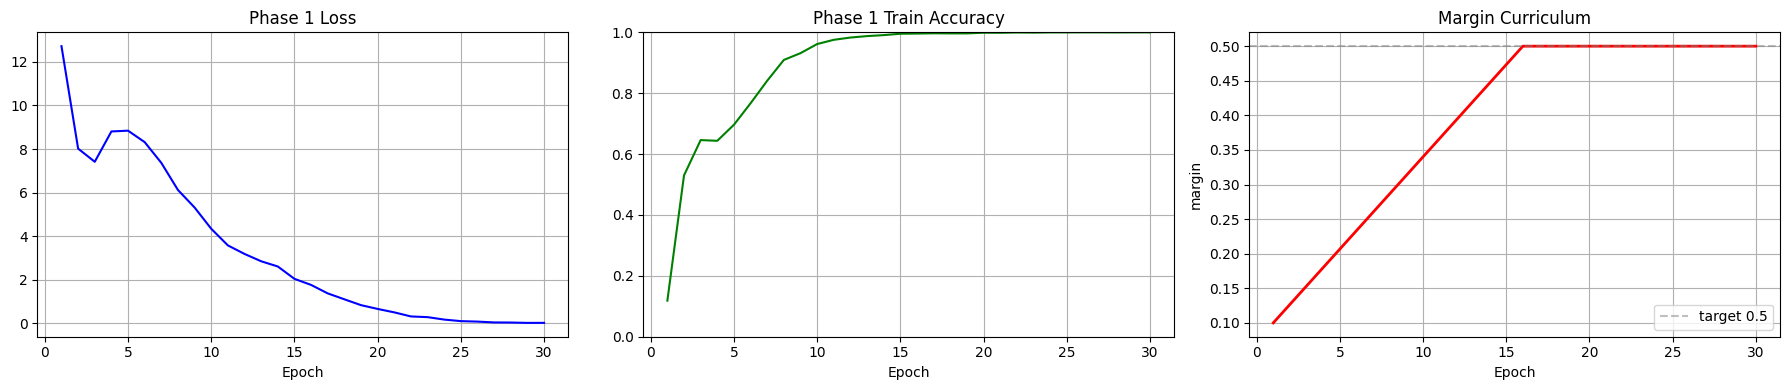

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
e1 = range(1, N_P1+1)
axes[0].plot(e1, hist_p1['loss'], 'b-', lw=1.5)
axes[0].set_title('Phase 1 Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True)
axes[1].plot(e1, hist_p1['acc'], 'g-', lw=1.5)
axes[1].set_title('Phase 1 Train Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1); axes[1].grid(True)
axes[2].plot(e1, hist_p1['margin'], 'r-', lw=2)
axes[2].axhline(MARGIN_END, color='gray', linestyle='--', alpha=0.5, label=f'target {MARGIN_END}')
axes[2].set_title('Margin Curriculum'); axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('margin'); axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()

---
## Section 7 -- Phase 2: Fine-Tuning (15 epochs)

Freeze layers 1-3 of ResNet34; train only layer4 + head + ArcFace.
Per-sample mining EMA continues from Phase 1 (inherited weights).
Lower LR: backbone=2e-4, ArcFace=5e-4.

In [9]:
for name, p in backbone.named_parameters():
    p.requires_grad = not any(name.startswith(s) for s in ['conv1','bn1','layer1','layer2','layer3'])

n_frozen = sum(1 for p in backbone.parameters() if not p.requires_grad)
n_train  = sum(1 for p in backbone.parameters() if p.requires_grad)
print(f'Backbone -- Frozen: {n_frozen}  |  Trainable: {n_train}')

optimizer_p2 = torch.optim.Adam([
    {'params': [p for p in backbone.parameters() if p.requires_grad], 'lr': 2e-4},
    {'params': arc_head.parameters(), 'lr': 5e-4},
], weight_decay=1e-4)

N_P2      = 15
sched_p2  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=N_P2, eta_min=1e-6)
params_p2 = [p for p in backbone.parameters() if p.requires_grad] + list(arc_head.parameters())
hist_p2   = {'loss':[], 'acc':[]}

for epoch in range(N_P2):
    loader_p2 = make_mining_loader(sample_loss_ema)
    backbone.train(); arc_head.train()
    ep_loss = 0.0; correct = 0; total = 0; n_batches = 0

    for imgs, labels, idxs in tqdm(loader_p2, desc=f'P2 {epoch+1:02d}/{N_P2}', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        emb      = backbone(imgs)
        per_loss = arc_head(emb, labels, reduction='none')
        loss     = per_loss.mean()

        optimizer_p2.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params_p2, max_norm=1.0)
        optimizer_p2.step()

        with torch.no_grad():
            idxs_cpu = idxs.cpu()
            lv = per_loss.detach().cpu()
            sample_loss_ema[idxs_cpu] = 0.7 * sample_loss_ema[idxs_cpu] + 0.3 * lv

            cos_all = F.linear(F.normalize(emb,dim=1), F.normalize(arc_head.weight,dim=1))
            logits  = cos_all.view(-1, NUM_CLASSES, K_SUB).max(dim=2).values * arc_head.scale
            correct += (logits.argmax(1)==labels.long()).sum().item()
            total   += labels.size(0)
        ep_loss += loss.item(); n_batches += 1

    sched_p2.step()
    avg = ep_loss/n_batches; acc = correct/total
    hist_p2['loss'].append(avg); hist_p2['acc'].append(acc)
    print(f'P2 E{epoch+1:02d}/{N_P2}  loss={avg:.4f}  acc={acc:.3f}  lr={sched_p2.get_last_lr()[0]:.2e}')

Backbone -- Frozen: 87  |  Trainable: 26


P2 01/15:   0%|          | 0/108 [00:00<?, ?it/s]

P2 E01/15  loss=0.0514  acc=1.000  lr=1.98e-04


P2 02/15:   0%|          | 0/108 [00:00<?, ?it/s]

P2 E02/15  loss=0.0926  acc=1.000  lr=1.91e-04


...

P2 E13/15  loss=0.0722  acc=1.000  lr=9.60e-06


P2 14/15:   0%|          | 0/108 [00:00<?, ?it/s]

P2 E14/15  loss=0.2394  acc=0.999  lr=3.17e-06


P2 15/15:   0%|          | 0/108 [00:00<?, ?it/s]

P2 E15/15  loss=1.6132  acc=0.990  lr=1.00e-06


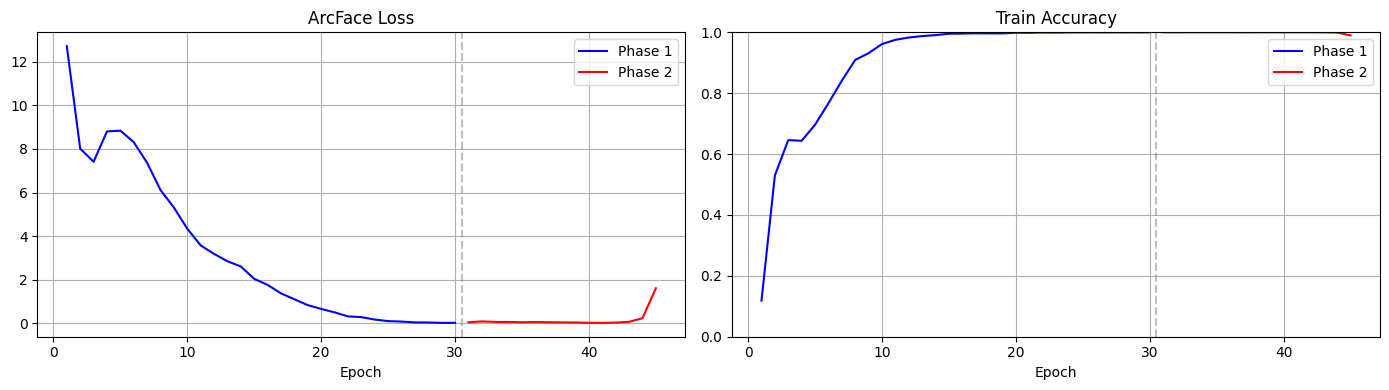

Phase 1 final: loss=0.0269  acc=1.000
Phase 2 final: loss=1.6132  acc=0.990


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
e1 = range(1, N_P1+1)
e2 = range(N_P1+1, N_P1+N_P2+1)
for ax, key, title in zip(axes, ['loss','acc'], ['ArcFace Loss','Train Accuracy']):
    ax.plot(e1, hist_p1[key], 'b-', lw=1.5, label='Phase 1')
    ax.plot(e2, hist_p2[key], 'r-', lw=1.5, label='Phase 2')
    ax.axvline(N_P1+0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True)
axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()
print(f'Phase 1 final: loss={hist_p1["loss"][-1]:.4f}  acc={hist_p1["acc"][-1]:.3f}')
print(f'Phase 2 final: loss={hist_p2["loss"][-1]:.4f}  acc={hist_p2["acc"][-1]:.3f}')

---
## Section 8 -- Phase 3: Contrastive Fine-Tuning on Genuine-Forgery Pairs

ArcFace training (Phases 1+2) never sees forgery images -- it only learns writer
classification on genuine signatures. Phase 3 directly optimises the verification
metric by fine-tuning on genuine-genuine (positive) and genuine-forgery (negative) pairs.

**Loss**: cosine contrastive loss, d = 1 - cosine_sim:
- Positive: L = d^2  (pull genuine pairs together)
- Negative: L = max(0, margin - d)^2  (push forgeries away by at least `margin`)

**Data**: GPDS150 genuine+forgery (150 training writers) + CEDAR training split (38 writers).
**Frozen**: layers 1-3 (same as Phase 2). Trains layer4 + embedding head only.

In [11]:
# Build Phase 3 dataset: GPDS (all writers have forgeries) + CEDAR train split
p3_wid_set = set(df_gpds['writer_uid'].unique()) | cedar_train_wids
df_p3 = pd.concat([
    df_gpds,
    df_cedar[df_cedar['writer_uid'].isin(cedar_train_wids)]
], ignore_index=True)

p3_ds = ForgeryPairDataset(df_p3, p3_wid_set, n_pairs=20000, seed=7,
                            neg_ratio=0.5, transform=eval_tfm)
p3_ld = DataLoader(p3_ds, batch_size=BATCH, shuffle=True, num_workers=0,
                   pin_memory=DEVICE.type=='cuda')

def cosine_contrastive_loss(emb1, emb2, labels, margin=0.4):
    """labels=1 positive, 0 negative. d = cosine distance in [0,2]."""
    sim = (F.normalize(emb1, dim=1) * F.normalize(emb2, dim=1)).sum(1)
    d   = 1.0 - sim
    pos = labels * d.pow(2)
    neg = (1.0 - labels) * F.relu(margin - d).pow(2)
    return (pos + neg).mean()

# layer1-3 already frozen from Phase 2; only layer4+head trainable
params_p3    = [p for p in backbone.parameters() if p.requires_grad]
optimizer_p3 = torch.optim.Adam(params_p3, lr=1e-5, weight_decay=1e-4)
N_P3         = 10
sched_p3     = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p3, T_max=N_P3, eta_min=1e-7)
hist_p3      = {'loss':[]}

for epoch in range(N_P3):
    backbone.train()
    ep_loss = 0.0; n_batches = 0

    for ia, ib, lbls in tqdm(p3_ld, desc=f'P3 {epoch+1:02d}/{N_P3}', leave=False):
        ia, ib, lbls = ia.to(DEVICE), ib.to(DEVICE), lbls.to(DEVICE)
        ea   = backbone(ia)
        eb   = backbone(ib)
        loss = cosine_contrastive_loss(ea, eb, lbls, margin=0.4)

        optimizer_p3.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params_p3, max_norm=1.0)
        optimizer_p3.step()
        ep_loss += loss.item(); n_batches += 1

    sched_p3.step()
    avg = ep_loss / n_batches
    hist_p3['loss'].append(avg)
    print(f'P3 E{epoch+1:02d}/{N_P3}  contrastive_loss={avg:.4f}  lr={sched_p3.get_last_lr()[0]:.2e}')

ForgeryPairDataset: 20,000 pairs from 188 writers (10000 pos / 10000 neg)


P3 01/10:   0%|          | 0/313 [00:00<?, ?it/s]

P3 E01/10  contrastive_loss=0.0178  lr=9.76e-06


P3 02/10:   0%|          | 0/313 [00:00<?, ?it/s]

P3 E02/10  contrastive_loss=0.0162  lr=9.05e-06


...

P3 E08/10  contrastive_loss=0.0110  lr=1.05e-06


P3 09/10:   0%|          | 0/313 [00:00<?, ?it/s]

P3 E09/10  contrastive_loss=0.0108  lr=3.42e-07


P3 10/10:   0%|          | 0/313 [00:00<?, ?it/s]

P3 E10/10  contrastive_loss=0.0108  lr=1.00e-07


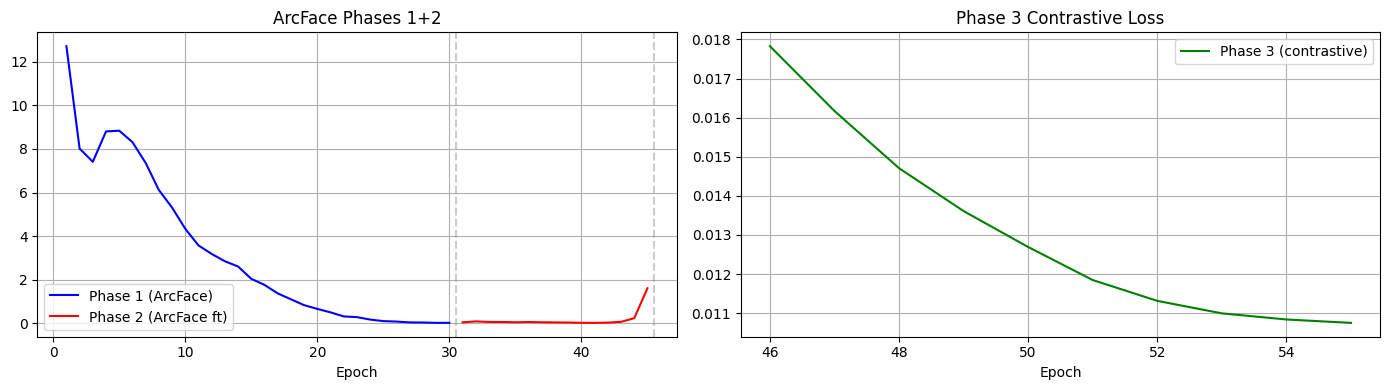

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
e1 = range(1, N_P1+1)
e2 = range(N_P1+1, N_P1+N_P2+1)
e3 = range(N_P1+N_P2+1, N_P1+N_P2+N_P3+1)
axes[0].plot(e1, hist_p1['loss'], 'b-', lw=1.5, label='Phase 1 (ArcFace)')
axes[0].plot(e2, hist_p2['loss'], 'r-', lw=1.5, label='Phase 2 (ArcFace ft)')
axes[0].axvline(N_P1+0.5, color='gray', linestyle='--', alpha=0.4)
axes[0].axvline(N_P1+N_P2+0.5, color='gray', linestyle='--', alpha=0.4)
axes[0].set_title('ArcFace Phases 1+2'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(e3, hist_p3['loss'], 'g-', lw=1.5, label='Phase 3 (contrastive)')
axes[1].set_title('Phase 3 Contrastive Loss'); axes[1].legend(); axes[1].grid(True)
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout(); plt.show()

---
## Section 9 -- Evaluation Pairs (CEDAR test set)

In [13]:
def build_pools(df, wid_set):
    gen, forg = {}, {}
    for wid, grp in df[df['writer_uid'].isin(wid_set)].groupby('writer_uid'):
        g = grp[grp['label']=='genuine']['path'].tolist()
        f = grp[grp['label']=='forgery']['path'].tolist()
        if g: gen[wid]  = g
        if f: forg[wid] = f
    return gen, forg

def generate_pairs(df, wid_set, n_pairs=10000, seed=1, neg_mix=0.8):
    gen, forg = build_pools(df, wid_set)
    writers   = sorted(gen); wf = sorted(set(gen)&set(forg))
    rng       = np.random.default_rng(seed)
    n_pos = n_pairs//2; n_neg = n_pairs-n_pos
    n_ns  = int(round(n_neg*neg_mix)); n_nc = n_neg-n_ns
    rows  = []
    for _ in range(n_pos):
        w=rng.choice(writers); g=gen[w]; i,j=rng.choice(len(g),size=2,replace=False)
        rows.append({'path_a':g[i],'path_b':g[j],'label':1,'pair_type':'pos'})
    for _ in range(n_ns):
        w=rng.choice(wf); g=gen[w]; f=forg[w]
        rows.append({'path_a':g[rng.integers(len(g))],'path_b':f[rng.integers(len(f))],'label':0,'pair_type':'neg_same'})
    for _ in range(n_nc):
        w1,w2=rng.choice(writers,size=2,replace=False)
        rows.append({'path_a':gen[w1][rng.integers(len(gen[w1]))],'path_b':gen[w2][rng.integers(len(gen[w2]))],'label':0,'pair_type':'neg_cross'})
    return pd.DataFrame(rows).sample(frac=1,random_state=seed).reset_index(drop=True)

def make_hard_pairs(df, wid_set, seed=5):
    gen, forg = build_pools(df, wid_set)
    rng = np.random.default_rng(seed); rows = []
    for w in sorted(set(gen)&set(forg)):
        g,f = gen[w],forg[w]
        for gi in g:
            for fi in f:
                rows.append({'path_a':gi,'path_b':fi,'label':0,'pair_type':'neg_same'})
        for _ in range(len(g)*len(f)):
            i,j=rng.choice(len(g),size=2,replace=False)
            rows.append({'path_a':g[i],'path_b':g[j],'label':1,'pair_type':'pos'})
    return pd.DataFrame(rows).sample(frac=1,random_state=seed).reset_index(drop=True)

test_pairs = generate_pairs(df_cedar, cedar_test_wids, n_pairs=10000, seed=3)
hard_pairs = make_hard_pairs(df_cedar, cedar_test_wids, seed=5)

test_ld = DataLoader(SiamesePairDataset(test_pairs, eval_tfm), batch_size=BATCH, shuffle=False, num_workers=0)
hard_ld = DataLoader(SiamesePairDataset(hard_pairs, eval_tfm), batch_size=BATCH, shuffle=False, num_workers=0)
print(f'Standard pairs : {len(test_pairs):,}')
print(f'Hard-neg pairs : {len(hard_pairs):,}')

Standard pairs : 10,000
Hard-neg pairs : 10,368


---
## Section 10 -- Standard Metrics

In [14]:
def extract_sims(loader, backbone, device):
    backbone.eval()
    sims, labs = [], []
    with torch.no_grad():
        for ia, ib, lbl in tqdm(loader, desc='Eval', leave=False):
            e1 = F.normalize(backbone(ia.to(device)), dim=1)
            e2 = F.normalize(backbone(ib.to(device)), dim=1)
            sims.append((e1*e2).sum(1).cpu().numpy())
            labs.append(lbl.numpy())
    return np.concatenate(sims), np.concatenate(labs).astype(int)

for p in backbone.parameters(): p.requires_grad_(False)

sim_std, y_std = extract_sims(test_ld, backbone, DEVICE)
res_std = compute_metrics(y_std, sim_std)

print(f'Cosine sim (pos): {sim_std[y_std==1].mean():.4f}')
print(f'Cosine sim (neg): {sim_std[y_std==0].mean():.4f}')
print(f'Gap             : {sim_std[y_std==1].mean()-sim_std[y_std==0].mean():.4f}')
print()
print('=== Standard Metrics ===')
for k,v in res_std.items(): print(f'  {k:<20s}: {v:.4f}')

Eval:   0%|          | 0/157 [00:00<?, ?it/s]

Cosine sim (pos): 0.7977
Cosine sim (neg): 0.2849
Gap             : 0.5128

=== Standard Metrics ===
  auc                 : 0.9762
  eer                 : 0.0663
  eer_threshold       : 0.6309
  far                 : 0.0664
  frr                 : 0.0662
  accuracy            : 0.9337
  used_threshold      : 0.6309


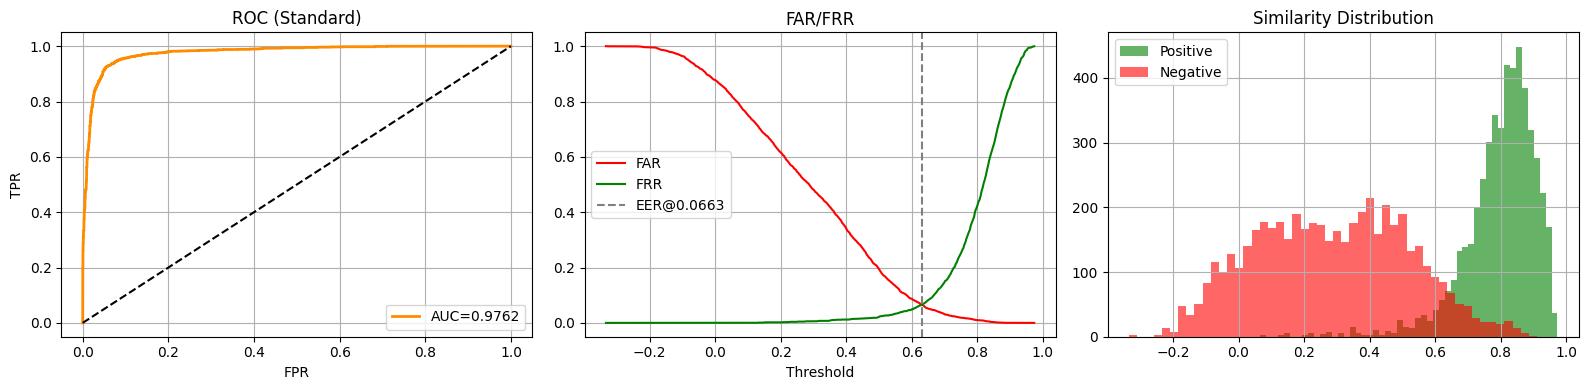

In [15]:
fpr,tpr,_ = sk_metrics.roc_curve(y_std, sim_std)
thr_range  = np.linspace(sim_std.min(), sim_std.max(), 400)
fa,fr = [],[]
for t in thr_range:
    p=(sim_std>=t).astype(int)
    tp=int(((p==1)&(y_std==1)).sum()); fp=int(((p==1)&(y_std==0)).sum())
    fn=int(((p==0)&(y_std==1)).sum()); tn=int(((p==0)&(y_std==0)).sum())
    fa.append(fp/(fp+tn) if fp+tn>0 else 0.); fr.append(fn/(fn+tp) if fn+tp>0 else 0.)
fa=np.array(fa); fr=np.array(fr)

fig,axes = plt.subplots(1,3,figsize=(16,4))
axes[0].plot(fpr,tpr,'darkorange',lw=2,label=f"AUC={res_std['auc']:.4f}")
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title('ROC (Standard)')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(thr_range,fa,'r-',label='FAR'); axes[1].plot(thr_range,fr,'g-',label='FRR')
axes[1].axvline(res_std['eer_threshold'],linestyle='--',color='gray',
                label=f"EER@{res_std['eer']:.4f}")
axes[1].set_title('FAR/FRR'); axes[1].set_xlabel('Threshold'); axes[1].legend(); axes[1].grid(True)
axes[2].hist(sim_std[y_std==1],bins=50,alpha=0.6,color='green',label='Positive')
axes[2].hist(sim_std[y_std==0],bins=50,alpha=0.6,color='red',  label='Negative')
axes[2].set_title('Similarity Distribution'); axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()

---
## Section 11 -- Hard-Negative Metrics (genuine vs skilled forgery)

Eval:   0%|          | 0/162 [00:00<?, ?it/s]

Hard -- sim (pos): 0.7976
Hard -- sim (neg): 0.2708
Hard -- gap      : 0.5268

=== Hard-Negative Metrics ===
  auc                 : 0.9765
  eer                 : 0.0663
  eer_threshold       : 0.6328
  far                 : 0.0662
  frr                 : 0.0664
  accuracy            : 0.9337
  used_threshold      : 0.6328


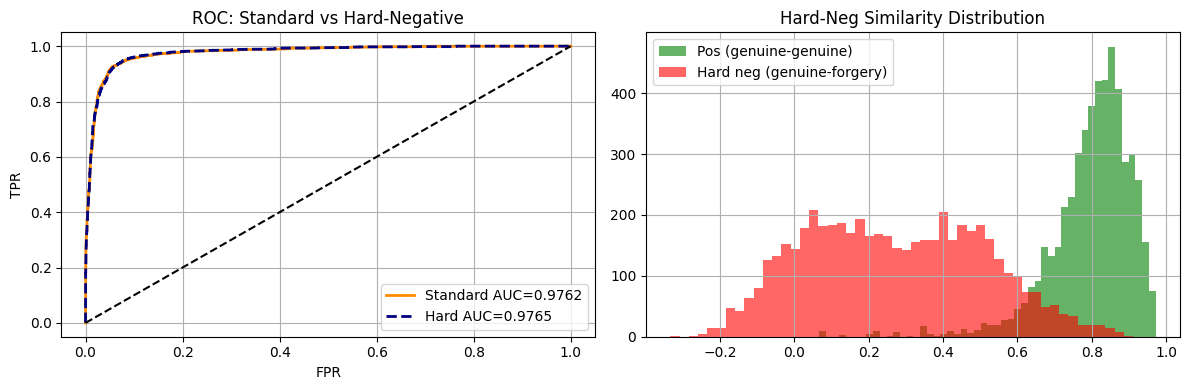

In [16]:
sim_hard, y_hard = extract_sims(hard_ld, backbone, DEVICE)
res_hard = compute_metrics(y_hard, sim_hard)

print(f'Hard -- sim (pos): {sim_hard[y_hard==1].mean():.4f}')
print(f'Hard -- sim (neg): {sim_hard[y_hard==0].mean():.4f}')
print(f'Hard -- gap      : {sim_hard[y_hard==1].mean()-sim_hard[y_hard==0].mean():.4f}')
print()
print('=== Hard-Negative Metrics ===')
for k,v in res_hard.items(): print(f'  {k:<20s}: {v:.4f}')

fpr_h,tpr_h,_ = sk_metrics.roc_curve(y_hard, sim_hard)
fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(fpr,   tpr,   'darkorange',lw=2,label=f"Standard AUC={res_std['auc']:.4f}")
axes[0].plot(fpr_h, tpr_h, 'navy',      lw=2,linestyle='--',label=f"Hard AUC={res_hard['auc']:.4f}")
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title('ROC: Standard vs Hard-Negative')
axes[0].legend(); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].grid(True)
axes[1].hist(sim_hard[y_hard==1],bins=50,alpha=0.6,color='green',label='Pos (genuine-genuine)')
axes[1].hist(sim_hard[y_hard==0],bins=50,alpha=0.6,color='red',  label='Hard neg (genuine-forgery)')
axes[1].set_title('Hard-Neg Similarity Distribution'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

---
## Section 12 -- Test-Time Augmentation (TTA, N=8)

Apply N=8 stochastic augmented views of each test image.
Average the L2-normalised embeddings, then re-normalise.
No retraining needed -- applied to the same checkpoint.

Running TTA (N=8) on standard test pairs...


TTA embed:   0%|          | 0/14 [00:00<?, ?it/s]

TTA sim (pos): 0.8114
TTA sim (neg): 0.2912
TTA gap      : 0.5203

=== TTA Metrics (N=8) ===
  auc                 : 0.9762
  eer                 : 0.0640
  eer_threshold       : 0.6470
  far                 : 0.0640
  frr                 : 0.0640
  accuracy            : 0.9360
  used_threshold      : 0.6470

EER improvement from TTA: 0.0023


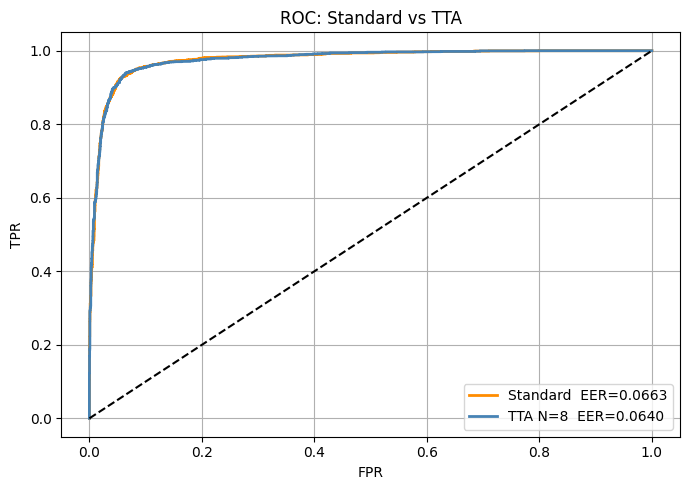

In [17]:
def embed_with_tta(paths, backbone, device, tta_tfm, n_tta=8, batch_size=32):
    """Embed a list of image paths with TTA. Caches by path position."""
    backbone.eval()
    all_embs = np.zeros((len(paths), EMB_DIM), dtype=np.float32)
    with torch.no_grad():
        for i in tqdm(range(0, len(paths), batch_size), desc='TTA embed', leave=False):
            bpaths = paths[i:i+batch_size]
            n = len(bpaths)
            avg = torch.zeros(n, EMB_DIM, device=device)
            for _ in range(n_tta):
                imgs = torch.stack([tta_tfm(Image.open(p).convert('L')) for p in bpaths]).to(device)
                avg += F.normalize(backbone(imgs), dim=1)
            all_embs[i:i+n] = F.normalize(avg, dim=1).cpu().numpy()
    return all_embs

def extract_sims_tta(pairs_df, backbone, device, tta_tfm, n_tta=8):
    # Embed only unique images (many are shared across pairs)
    all_paths = list(dict.fromkeys(pairs_df['path_a'].tolist() + pairs_df['path_b'].tolist()))
    p2i       = {p: i for i, p in enumerate(all_paths)}
    embs      = embed_with_tta(all_paths, backbone, device, tta_tfm, n_tta=n_tta)
    idx_a = [p2i[p] for p in pairs_df['path_a']]
    idx_b = [p2i[p] for p in pairs_df['path_b']]
    sims  = (embs[idx_a] * embs[idx_b]).sum(1)
    labs  = pairs_df['label'].values.astype(int)
    return sims, labs

N_TTA = 8
print(f'Running TTA (N={N_TTA}) on standard test pairs...')
sim_tta, y_tta = extract_sims_tta(test_pairs, backbone, DEVICE, tta_tfm, n_tta=N_TTA)
res_tta = compute_metrics(y_tta, sim_tta)

print(f'TTA sim (pos): {sim_tta[y_tta==1].mean():.4f}')
print(f'TTA sim (neg): {sim_tta[y_tta==0].mean():.4f}')
print(f'TTA gap      : {sim_tta[y_tta==1].mean()-sim_tta[y_tta==0].mean():.4f}')
print()
print('=== TTA Metrics (N=8) ===')
for k,v in res_tta.items(): print(f'  {k:<20s}: {v:.4f}')
print()
print(f'EER improvement from TTA: {res_std["eer"] - res_tta["eer"]:.4f}')

fpr_t,tpr_t,_ = sk_metrics.roc_curve(y_tta, sim_tta)
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(fpr,   tpr,   'darkorange', lw=2, label=f"Standard  EER={res_std['eer']:.4f}")
ax.plot(fpr_t, tpr_t, 'steelblue',  lw=2, label=f"TTA N={N_TTA}  EER={res_tta['eer']:.4f}")
ax.plot([0,1],[0,1],'k--'); ax.set_title('ROC: Standard vs TTA')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## Section 13 -- Embedding Space (PCA)

PCA:   0%|          | 0/4 [00:00<?, ?it/s]

PCA explained variance: 42.12%


/tmp/ipykernel_175/2229134029.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(cedar_test_wids))


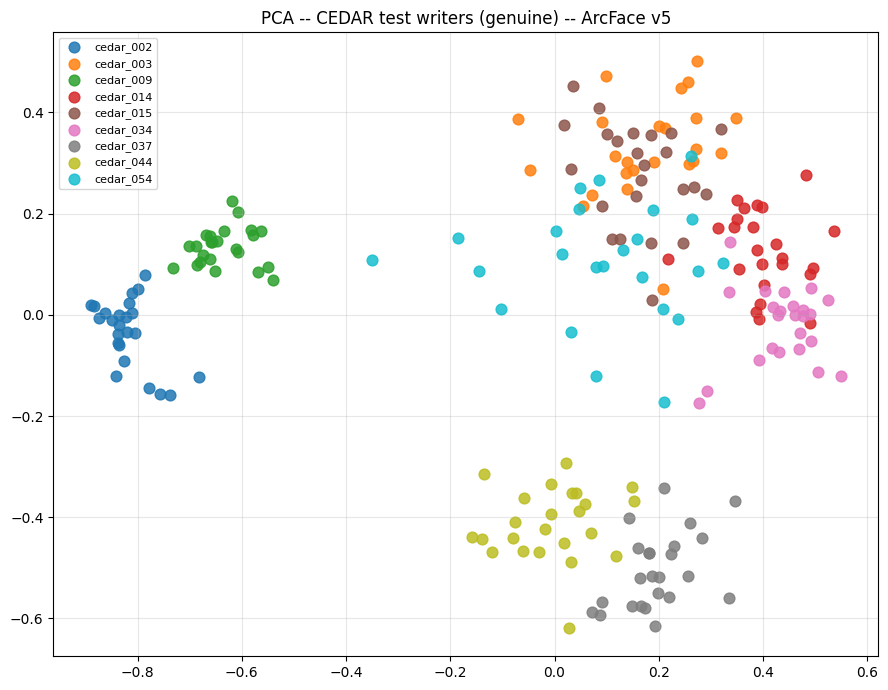

In [18]:
test_w2c   = {wid:i for i,wid in enumerate(sorted(cedar_test_wids))}
test_gen   = SignatureClassDataset(df_cedar, test_w2c, cedar_test_wids, transform=eval_tfm)
test_gen_l = DataLoader(test_gen, batch_size=BATCH, shuffle=False, num_workers=0)

backbone.eval()
all_e, all_w = [], []
with torch.no_grad():
    for imgs, cls, _ in tqdm(test_gen_l, desc='PCA', leave=False):
        all_e.append(F.normalize(backbone(imgs.to(DEVICE)),dim=1).cpu().numpy())
        all_w.append(cls.numpy())
all_e = np.concatenate(all_e); all_w = np.concatenate(all_w)

pca = PCA(n_components=2, random_state=SEED)
e2d = pca.fit_transform(all_e)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}')

fig, ax = plt.subplots(figsize=(9,7))
cmap = plt.cm.get_cmap('tab10', len(cedar_test_wids))
for i, wid in enumerate(sorted(test_w2c)):
    mask = all_w==test_w2c[wid]
    ax.scatter(e2d[mask,0], e2d[mask,1], color=cmap(i), label=wid, s=60, alpha=0.85)
ax.set_title('PCA -- CEDAR test writers (genuine) -- ArcFace v5')
ax.legend(loc='best', fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Section 14 -- Summary

In [19]:
from IPython.display import Markdown, display

gap_std  = sim_std[y_std==1].mean()  - sim_std[y_std==0].mean()
gap_hard = sim_hard[y_hard==1].mean()- sim_hard[y_hard==0].mean()
gap_tta  = sim_tta[y_tta==1].mean()  - sim_tta[y_tta==0].mean()

std_rows  = '\n'.join(f'| {k:<22s} | {v:.4f} |' for k,v in res_std.items())
hard_rows = '\n'.join(f'| {k:<22s} | {v:.4f} |' for k,v in res_hard.items())
tta_rows  = '\n'.join(f'| {k:<22s} | {v:.4f} |' for k,v in res_tta.items())

display(Markdown(f'''
### ArcFace v5 -- CEDAR test writers

#### Standard evaluation (10k pairs, 80% same-writer forgeries)
| Metric                   | Value  |
|:-------------------------|-------:|
{std_rows}

#### Hard-negative (genuine vs skilled forgery only)
| Metric                   | Value  |
|:-------------------------|-------:|
{hard_rows}

#### TTA N=8 (standard pairs, stochastic augmented views)
| Metric                   | Value  |
|:-------------------------|-------:|
{tta_rows}

### Version comparison
| Metric       | v1 SmallCNN 38cls | v2 ResNet18 38cls | v3 ResNet18-PT 251cls | v4 +mining | v5 this run |
|:-------------|:-----------------:|:-----------------:|:---------------------:|:----------:|:-----------:|
| AUC          | 0.8477 | 0.9320 | 0.9671 | 0.9790 | {res_std["auc"]:.4f} |
| EER          | 0.2584 | 0.1374 | 0.0889 | 0.0791 | {res_std["eer"]:.4f} |
| EER (hard)   | --     | --     | 0.0910 | 0.0765 | {res_hard["eer"]:.4f} |
| EER (TTA)    | --     | --     | --     | --     | {res_tta["eer"]:.4f} |
| Cosine gap   | 0.0196 | 0.4434 | 0.4415 | 0.5172 | {gap_std:.4f} |
| EER threshold| 0.9972 | 0.7131 | 0.5162 | 0.5014 | {res_std["eer_threshold"]:.4f} |
'''))


### ArcFace v5 -- CEDAR test writers

#### Standard evaluation (10k pairs, 80% same-writer forgeries)
| Metric                   | Value  |
|:-------------------------|-------:|
| auc                    | 0.9762 |
| eer                    | 0.0663 |
| eer_threshold          | 0.6309 |
| far                    | 0.0664 |
| frr                    | 0.0662 |
| accuracy               | 0.9337 |
| used_threshold         | 0.6309 |

#### Hard-negative (genuine vs skilled forgery only)
| Metric                   | Value  |
|:-------------------------|-------:|
| auc                    | 0.9765 |
| eer                    | 0.0663 |
| eer_threshold          | 0.6328 |
| far                    | 0.0662 |
| frr                    | 0.0664 |
| accuracy               | 0.9337 |
| used_threshold         | 0.6328 |

#### TTA N=8 (standard pairs, stochastic augmented views)
| Metric                   | Value  |
|:-------------------------|-------:|
| auc                    | 0.9762 |
| eer                    | 0.0640 |
| eer_threshold          | 0.6470 |
| far                    | 0.0640 |
| frr                    | 0.0640 |
| accuracy               | 0.9360 |
| used_threshold         | 0.6470 |

### Version comparison
| Metric       | v1 SmallCNN 38cls | v2 ResNet18 38cls | v3 ResNet18-PT 251cls | v4 +mining | v5 this run |
|:-------------|:-----------------:|:-----------------:|:---------------------:|:----------:|:-----------:|
| AUC          | 0.8477 | 0.9320 | 0.9671 | 0.9790 | 0.9762 |
| EER          | 0.2584 | 0.1374 | 0.0889 | 0.0791 | 0.0663 |
| EER (hard)   | --     | --     | 0.0910 | 0.0765 | 0.0663 |
| EER (TTA)    | --     | --     | --     | --     | 0.0640 |
| Cosine gap   | 0.0196 | 0.4434 | 0.4415 | 0.5172 | 0.5128 |
| EER threshold| 0.9972 | 0.7131 | 0.5162 | 0.5014 | 0.6309 |
